
  # PHASE 1 — Data Loading & Exploration
  Arabic → English Neural Machine Translation


CELL 1 — Install & import libraries

In [ ]:
import requests
import matplotlib
import matplotlib.pyplot as plt
import re
from collections import Counter

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


CELL 2 — Download the dataset from GitHub

In [ ]:
URL = "https://raw.githubusercontent.com/SamirMoustafa/nmt-with-attention-for-ar-to-en/master/ara_.txt"

print("Downloading dataset...")


response = requests.get(URL)

if response.status_code == 200:
    print("✅ Download successful!")
else:
    print(f"❌ Download failed. Status code: {response.status_code}")

with open("ara_.txt", "w", encoding="utf-8") as f:
    f.write(response.text)

print("✅ File saved as ara_.txt")


✅ Download successful!
✅ File saved as ara_.txt


CELL 3 — Load and parse the file

In [ ]:
# Each line in the file looks like this:
#   Go.	اذهب.	CC-BY 2.0 ...
# Fields are separated by TAB characters (\t)
# We only want the first two columns: English and Arabic

pairs = []  # this will hold our list of (arabic, english) tuples

with open("ara_.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()          # remove whitespace / newlines at edges
        if not line:                 # skip empty lines
            continue
        parts = line.split("\t")     # split by TAB character
        if len(parts) >= 2:
            english = parts[0].strip()   # first column = English
            arabic  = parts[1].strip()   # second column = Arabic
            pairs.append((arabic, english))  # store as (arabic, english)

print(f"✅ Loaded {len(pairs):,} sentence pairs")

✅ Loaded 10,742 sentence pairs


 CELL 4 — Preview the data (sanity check)

In [ ]:
print("=" * 60)
print("SAMPLE SENTENCE PAIRS")
print("=" * 60)

for i, (arabic, english) in enumerate(pairs[:15]):
    # The \u202b character forces right-to-left display for Arabic
    print(f"[{i+1:02d}] AR: \u202b{arabic}")
    print(f"      EN: {english}")
    print()

SAMPLE SENTENCE PAIRS
[01] AR: ‫مرحبًا.
      EN: Hi.

[02] AR: ‫اركض!
      EN: Run!

[03] AR: ‫النجدة!
      EN: Help!

[04] AR: ‫اقفز!
      EN: Jump!

[05] AR: ‫قف!
      EN: Stop!

[06] AR: ‫داوم.
      EN: Go on.

[07] AR: ‫استمر.
      EN: Go on.

[08] AR: ‫مرحباً.
      EN: Hello!

[09] AR: ‫تعجّل!
      EN: Hurry!

[10] AR: ‫استعجل!
      EN: Hurry!

[11] AR: ‫انا اري
      EN: I see.

[12] AR: ‫أنا فُزت!
      EN: I won!

[13] AR: ‫ابتسم.
      EN: Smile.

[14] AR: ‫في صحتك.
      EN: Cheers!

[15] AR: ‫هل فهمت؟
      EN: Got it?



 CELL 5 — Basic statistics

In [ ]:
# Count how many words are in each sentence.
# split() breaks a string into a list of words by spaces.
# Example: "hello world".split() → ["hello", "world"] → length 2

ar_lengths = [len(ar.split()) for ar, en in pairs]   # word count per Arabic sentence
en_lengths = [len(en.split()) for ar, en in pairs]   # word count per English sentence

print("=" * 60)
print("DATASET STATISTICS")
print("=" * 60)
print(f"Total sentence pairs : {len(pairs):,}")
print()
print("Arabic sentences:")
print(f"  Shortest  : {min(ar_lengths)} words")
print(f"  Longest   : {max(ar_lengths)} words")
print(f"  Average   : {sum(ar_lengths)/len(ar_lengths):.1f} words")
print()
print("English sentences:")
print(f"  Shortest  : {min(en_lengths)} words")
print(f"  Longest   : {max(en_lengths)} words")
print(f"  Average   : {sum(en_lengths)/len(en_lengths):.1f} words")

DATASET STATISTICS
Total sentence pairs : 10,742

Arabic sentences:
  Shortest  : 1 words
  Longest   : 36 words
  Average   : 4.4 words

English sentences:
  Shortest  : 1 words
  Longest   : 34 words
  Average   : 5.7 words


CELL 6 — Vocabulary size

In [ ]:
# A "vocabulary" is just the set of all unique words in the data.
# set() automatically removes duplicates.
# Example: {"hello", "world", "hello"} → {"hello", "world"}  (size = 2)

# We flatten all sentences into one big list of words, then count unique ones
all_arabic_words  = [word for ar, en in pairs for word in ar.split()]
all_english_words = [word for ar, en in pairs for word in en.split()]

arabic_vocab  = set(all_arabic_words)   # unique Arabic words
english_vocab = set(all_english_words)  # unique English words

print("=" * 60)
print("VOCABULARY SIZE")
print("=" * 60)
print(f"Unique Arabic words  : {len(arabic_vocab):,}")
print(f"Unique English words : {len(english_vocab):,}")
print()

# Also show the 10 most common words in each language
# Counter counts how many times each word appears
arabic_counts  = Counter(all_arabic_words)
english_counts = Counter(all_english_words)

print("10 most common Arabic words:")
for word, count in arabic_counts.most_common(10):
    print(f"  {word:20s}  →  {count:,} times")

print()
print("10 most common English words:")
for word, count in english_counts.most_common(10):
    print(f"  {word:20s}  →  {count:,} times")

VOCABULARY SIZE
Unique Arabic words  : 13,794
Unique English words : 6,704

10 most common Arabic words:
  من                    →  1,072 times
  أن                    →  1,011 times
  في                    →  858 times
  لا                    →  817 times
  توم                   →  768 times
  هل                    →  593 times
  ما                    →  543 times
  إلى                   →  525 times
  أنا                   →  524 times
  على                   →  477 times

10 most common English words:
  I                     →  2,322 times
  to                    →  1,933 times
  the                   →  1,701 times
  you                   →  1,456 times
  a                     →  1,394 times
  is                    →  1,196 times
  Tom                   →  812 times
  in                    →  609 times
  of                    →  579 times
  He                    →  537 times


 CELL 7 — Plot sentence length distribution

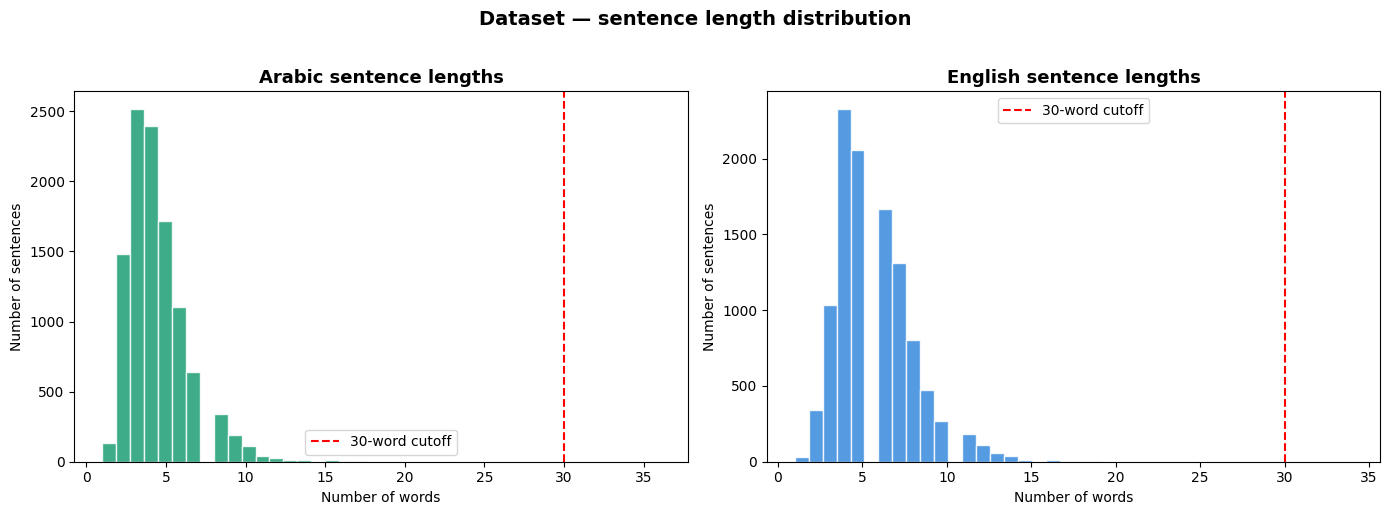

✅ Chart saved as length_distribution.png


In [ ]:
# A histogram shows us how sentence lengths are distributed.
# Most sentences should be short (5-15 words).
# Very long sentences (50+ words) are rare and slow to train on.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
# plt.subplots(1, 2) creates 1 row, 2 columns of charts side by side

# --- Arabic histogram ---
ax1.hist(ar_lengths, bins=40, color="#1D9E75", edgecolor="white", alpha=0.85)
# bins=40 means we divide the range of lengths into 40 bars
ax1.set_title("Arabic sentence lengths", fontsize=13, fontweight="bold")
ax1.set_xlabel("Number of words")
ax1.set_ylabel("Number of sentences")
ax1.axvline(x=30, color="red", linestyle="--", linewidth=1.5, label="30-word cutoff")
# The red dashed line marks where we might filter out very long sentences later
ax1.legend()

# --- English histogram ---
ax2.hist(en_lengths, bins=40, color="#378ADD", edgecolor="white", alpha=0.85)
ax2.set_title("English sentence lengths", fontsize=13, fontweight="bold")
ax2.set_xlabel("Number of words")
ax2.set_ylabel("Number of sentences")
ax2.axvline(x=30, color="red", linestyle="--", linewidth=1.5, label="30-word cutoff")
ax2.legend()

plt.suptitle("Dataset — sentence length distribution", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("length_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Chart saved as length_distribution.png")


CELL 8 — Decide on a max sentence length

In [ ]:
# From the histogram, we choose a cutoff.
# Sentences longer than MAX_LEN words will be removed in Phase 2.
# This keeps training fast without losing too much data.
# A typical starting value is 30 words.

MAX_LEN = 30  # you can adjust this after seeing the histogram

# Count how many pairs we KEEP vs REMOVE
kept    = sum(1 for ar, en in pairs if len(ar.split()) <= MAX_LEN and len(en.split()) <= MAX_LEN)
removed = len(pairs) - kept

print("=" * 60)
print(f"MAX sentence length set to: {MAX_LEN} words")
print(f"Pairs kept    : {kept:,}  ({100*kept/len(pairs):.1f}%)")
print(f"Pairs removed : {removed:,}  ({100*removed/len(pairs):.1f}%)")
print("=" * 60)
print()
print("✅ Phase 1 complete! Move on to Phase 2 — Preprocessing.")

MAX sentence length set to: 30 words
Pairs kept    : 10,741  (100.0%)
Pairs removed : 1  (0.0%)

✅ Phase 1 complete! Move on to Phase 2 — Preprocessing.


*italicized text*# New Section

PHASE 2 — Text Preprocessing & Tokenization

# PHASE 2 — Text Preprocessing & Tokenization

CELL 1 — Import libraries

In [ ]:
import re                        # for cleaning text with rules
import numpy as np               # for working with number arrays
from collections import Counter  # for counting word frequencies

print("✅ Libraries imported!")

✅ Libraries imported!


CELL 2 — Re-load the data

In [ ]:
pairs = []
with open("ara_.txt", "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        parts = line.split("\t")
        if len(parts) >= 2:
            english = parts[0].strip()
            arabic  = parts[1].strip()
            pairs.append((arabic, english))

print(f"✅ Reloaded {len(pairs):,} sentence pairs")


✅ Reloaded 10,742 sentence pairs


CELL 3 — Clean the text

In [ ]:
# Raw text has punctuation, numbers, and special characters that
# confuse the model. We strip everything except letters and spaces.

def clean_arabic(text):
    """
    Cleans an Arabic sentence:
    - Removes punctuation and non-Arabic characters
    - Keeps only Arabic Unicode letters (range \u0600–\u06FF)
    - Lowercases is not needed for Arabic (it has no case)
    - Strips extra whitespace
    """
    # Keep only Arabic letters and spaces; remove everything else
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    # Collapse multiple spaces into one
    text = re.sub(r"\s+", " ", text).strip()
    return text

def clean_english(text):
    """
    Cleans an English sentence:
    - Converts to lowercase (Hello = hello for the model)
    - Removes punctuation
    - Strips extra whitespace
    """
    text = text.lower()                        # lowercase everything
    text = re.sub(r"[^a-z\s]", "", text)       # keep only letters and spaces
    text = re.sub(r"\s+", " ", text).strip()   # remove extra spaces
    return text

# Apply cleaning to every pair
cleaned_pairs = []
for arabic, english in pairs:
    ar_clean = clean_arabic(arabic)
    en_clean = clean_english(english)
    # Only keep the pair if both sides are non-empty after cleaning
    if ar_clean and en_clean:
        cleaned_pairs.append((ar_clean, en_clean))

print(f"✅ Cleaned pairs: {len(cleaned_pairs):,}")
print()
print("Before vs After cleaning (first 5 pairs):")
print("-" * 55)
for i in range(5):
    ar_orig, en_orig = pairs[i]
    ar_cln,  en_cln  = cleaned_pairs[i]
    print(f"AR original : {ar_orig}")
    print(f"AR cleaned  : {ar_cln}")
    print(f"EN original : {en_orig}")
    print(f"EN cleaned  : {en_cln}")
    print()


✅ Cleaned pairs: 10,741

Before vs After cleaning (first 5 pairs):
-------------------------------------------------------
AR original : مرحبًا.
AR cleaned  : مرحبًا
EN original : Hi.
EN cleaned  : hi

AR original : اركض!
AR cleaned  : اركض
EN original : Run!
EN cleaned  : run

AR original : النجدة!
AR cleaned  : النجدة
EN original : Help!
EN cleaned  : help

AR original : اقفز!
AR cleaned  : اقفز
EN original : Jump!
EN cleaned  : jump

AR original : قف!
AR cleaned  : قف
EN original : Stop!
EN cleaned  : stop



CELL 4 — Filter by sentence length

In [ ]:
# As decided in Phase 1, we remove sentences longer than 30 words.
# Very long sentences slow down training without adding much value.

MAX_LEN = 30

filtered_pairs = [
    (ar, en) for ar, en in cleaned_pairs
    if len(ar.split()) <= MAX_LEN and len(en.split()) <= MAX_LEN
]

print(f"✅ Pairs after length filter (max {MAX_LEN} words): {len(filtered_pairs):,}")
print(f"   Removed: {len(cleaned_pairs) - len(filtered_pairs):,} pairs")

✅ Pairs after length filter (max 30 words): 10,740
   Removed: 1 pairs


CELL 5 — Build vocabularies

In [ ]:
# A vocabulary is a dictionary that maps every word to a unique number.
# Example:  { "hello": 4,  "world": 5,  "the": 6, ... }
#
# We also add 4 special tokens that the Transformer needs:
#
#   <PAD> = 0  → "Padding" — used to make all sentences the same length
#   <SOS> = 1  → "Start of Sentence" — tells the decoder to begin translating
#   <EOS> = 2  → "End of Sentence"   — tells the decoder to stop translating
#   <UNK> = 3  → "Unknown"           — represents any word not in the vocabulary

SPECIAL_TOKENS = ["<PAD>", "<SOS>", "<EOS>", "<UNK>"]
PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

def build_vocab(sentences, min_freq=2):
    """
    Builds a word-to-index vocabulary from a list of sentences.

    min_freq: words that appear fewer than this many times are ignored.
    This removes rare typos and very uncommon words that the model
    won't have enough examples to learn from.
    """
    # Count how often every word appears
    counter = Counter()
    for sentence in sentences:
        counter.update(sentence.split())

    # Start vocab with the 4 special tokens
    vocab = {token: idx for idx, token in enumerate(SPECIAL_TOKENS)}

    # Add every word that appears at least min_freq times
    for word, freq in counter.items():
        if freq >= min_freq:
            vocab[word] = len(vocab)  # next available index

    return vocab

# Separate Arabic and English sentences into two lists
arabic_sentences  = [ar for ar, en in filtered_pairs]
english_sentences = [en for ar, en in filtered_pairs]

# Build one vocab for Arabic, one for English
arabic_vocab  = build_vocab(arabic_sentences,  min_freq=2)
english_vocab = build_vocab(english_sentences, min_freq=2)

# Also build reverse dictionaries: number → word (needed to convert output back to text)
idx_to_arabic  = {idx: word for word, idx in arabic_vocab.items()}
idx_to_english = {idx: word for word, idx in english_vocab.items()}

print("=" * 50)
print("VOCABULARY SIZES")
print("=" * 50)
print(f"Arabic  vocabulary : {len(arabic_vocab):,} words")
print(f"English vocabulary : {len(english_vocab):,} words")
print()
print("Sample Arabic vocab entries:")
sample_ar = list(arabic_vocab.items())[:8]
for word, idx in sample_ar:
    print(f"  '{word}' → {idx}")
print()
print("Sample English vocab entries:")
sample_en = list(english_vocab.items())[:8]
for word, idx in sample_en:
    print(f"  '{word}' → {idx}")


VOCABULARY SIZES
Arabic  vocabulary : 4,454 words
English vocabulary : 2,414 words

Sample Arabic vocab entries:
  '<PAD>' → 0
  '<SOS>' → 1
  '<EOS>' → 2
  '<UNK>' → 3
  'اركض' → 4
  'النجدة' → 5
  'اقفز' → 6
  'قف' → 7

Sample English vocab entries:
  '<PAD>' → 0
  '<SOS>' → 1
  '<EOS>' → 2
  '<UNK>' → 3
  'hi' → 4
  'run' → 5
  'help' → 6
  'jump' → 7


CELL 6 — Tokenize sentences (words → numbers)

In [ ]:
# Tokenization = converting a sentence from words into a list of numbers.
#
# Example:
#   English sentence:  "go away"
#   After tokenizing:  [1, 45, 78, 2]
#                       ↑            ↑
#                      SOS          EOS
#
# The model reads these numbers, not the words themselves.

def tokenize(sentence, vocab):
    """
    Converts a sentence (string) into a list of integer indices.
    - Adds <SOS> at the start and <EOS> at the end
    - Any word not in the vocab gets replaced with <UNK>
    """
    tokens = [SOS_IDX]  # start with Start-Of-Sentence token
    for word in sentence.split():
        tokens.append(vocab.get(word, UNK_IDX))  # UNK if word not found
    tokens.append(EOS_IDX)  # finish with End-Of-Sentence token
    return tokens

# Tokenize every sentence pair
tokenized_pairs = [
    (tokenize(ar, arabic_vocab), tokenize(en, english_vocab))
    for ar, en in filtered_pairs
]

# Show a few examples to verify
print("=" * 55)
print("TOKENIZATION EXAMPLES")
print("=" * 55)
for i in range(3):
    ar_text, en_text = filtered_pairs[i]
    ar_tokens, en_tokens = tokenized_pairs[i]
    print(f"Arabic  text   : {ar_text}")
    print(f"Arabic  tokens : {ar_tokens}")
    print(f"English text   : {en_text}")
    print(f"English tokens : {en_tokens}")
    print()

TOKENIZATION EXAMPLES
Arabic  text   : مرحبًا
Arabic  tokens : [1, 3, 2]
English text   : hi
English tokens : [1, 4, 2]

Arabic  text   : اركض
Arabic  tokens : [1, 4, 2]
English text   : run
English tokens : [1, 5, 2]

Arabic  text   : النجدة
Arabic  tokens : [1, 5, 2]
English text   : help
English tokens : [1, 6, 2]



CELL 7 — Pad sequences to equal length

In [ ]:
# The Transformer processes sentences in batches (groups of sentences at once).
# But sentences have different lengths — we can't stack them into a grid unless
# they're all the same length.
#
# Solution: PAD shorter sentences with zeros (PAD token = 0) on the right.
#
# Example (MAX_LEN = 6):
#   [1, 45, 78, 2]           →  [1, 45, 78,  2,  0,  0]
#   [1, 12, 34, 56, 89, 2]   →  [1, 12, 34, 56, 89,  2]

def pad_sequence(tokens, max_len, pad_idx=PAD_IDX):
    """
    Pads (or truncates) a token list to exactly max_len length.
    """
    if len(tokens) < max_len:
        # Add PAD tokens to the right
        tokens = tokens + [pad_idx] * (max_len - len(tokens))
    else:
        # Truncate if somehow still too long
        tokens = tokens[:max_len]
    return tokens

# +2 because we added <SOS> and <EOS> to each sentence
MAX_SEQ_LEN = MAX_LEN + 2

# Pad every Arabic and English token sequence
ar_padded = [pad_sequence(ar, MAX_SEQ_LEN) for ar, en in tokenized_pairs]
en_padded = [pad_sequence(en, MAX_SEQ_LEN) for ar, en in tokenized_pairs]

# Convert to numpy arrays — these are the final inputs the model will train on
ar_array = np.array(ar_padded, dtype=np.int32)  # shape: (num_pairs, MAX_SEQ_LEN)
en_array = np.array(en_padded, dtype=np.int32)  # shape: (num_pairs, MAX_SEQ_LEN)

print("=" * 50)
print("PADDED ARRAYS")
print("=" * 50)
print(f"Arabic  array shape : {ar_array.shape}")
print(f"English array shape : {en_array.shape}")
print()
print("First Arabic padded sequence:")
print(ar_array[0])
print()
print("First English padded sequence:")
print(en_array[0])

PADDED ARRAYS
Arabic  array shape : (10740, 32)
English array shape : (10740, 32)

First Arabic padded sequence:
[1 3 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]

First English padded sequence:
[1 4 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


 CELL 8 — Train / Validation / Test split

In [ ]:
# We split our data into 3 groups:
#
#  Training set   (80%) — the model learns from this
#  Validation set (10%) — we check progress during training (model never trains on it)
#  Test set       (10%) — final evaluation after training is done

import random

random.seed(42)  # seed = 42 makes the shuffle reproducible (same result every time)

# Create a list of indices [0, 1, 2, ..., N-1] and shuffle it
indices = list(range(len(ar_array)))
random.shuffle(indices)

# Calculate split boundaries
n_total = len(indices)
n_train = int(0.80 * n_total)
n_val   = int(0.10 * n_total)
# Test gets whatever remains

train_idx = indices[:n_train]
val_idx   = indices[n_train : n_train + n_val]
test_idx  = indices[n_train + n_val:]

# Create the actual split arrays
ar_train, en_train = ar_array[train_idx], en_array[train_idx]
ar_val,   en_val   = ar_array[val_idx],   en_array[val_idx]
ar_test,  en_test  = ar_array[test_idx],  en_array[test_idx]

print("=" * 50)
print("TRAIN / VALIDATION / TEST SPLIT")
print("=" * 50)
print(f"Training   : {len(ar_train):,} pairs  (80%)")
print(f"Validation : {len(ar_val):,}  pairs  (10%)")
print(f"Test       : {len(ar_test):,}  pairs  (10%)")


TRAIN / VALIDATION / TEST SPLIT
Training   : 8,592 pairs  (80%)
Validation : 1,074  pairs  (10%)
Test       : 1,074  pairs  (10%)


CELL 9 — Save everything for Phase 3

In [ ]:
# We save the arrays and vocabularies so Phase 3 can load them directly.
# np.save() saves a numpy array to a .npy file.

import pickle  # pickle saves Python objects (like dictionaries) to files

# Save arrays
np.save("ar_train.npy", ar_train)
np.save("en_train.npy", en_train)
np.save("ar_val.npy",   ar_val)
np.save("en_val.npy",   en_val)
np.save("ar_test.npy",  ar_test)
np.save("en_test.npy",  en_test)

# Save vocabularies (as pickle files so we can reload the dicts)
with open("arabic_vocab.pkl",  "wb") as f: pickle.dump(arabic_vocab,  f)
with open("english_vocab.pkl", "wb") as f: pickle.dump(english_vocab, f)
with open("idx_to_arabic.pkl", "wb") as f: pickle.dump(idx_to_arabic, f)
with open("idx_to_english.pkl","wb") as f: pickle.dump(idx_to_english,f)

# Save useful config values
config = {
    "MAX_SEQ_LEN"    : MAX_SEQ_LEN,
    "ARABIC_VOCAB_SIZE" : len(arabic_vocab),
    "ENGLISH_VOCAB_SIZE": len(english_vocab),
    "PAD_IDX"        : PAD_IDX,
    "SOS_IDX"        : SOS_IDX,
    "EOS_IDX"        : EOS_IDX,
    "UNK_IDX"        : UNK_IDX,
}
with open("config.pkl", "wb") as f: pickle.dump(config, f)

print("=" * 50)
print("FILES SAVED")
print("=" * 50)
for fname in ["ar_train.npy","en_train.npy","ar_val.npy","en_val.npy",
              "ar_test.npy","en_test.npy","arabic_vocab.pkl",
              "english_vocab.pkl","idx_to_arabic.pkl","idx_to_english.pkl","config.pkl"]:
    print(f"  ✅ {fname}")

print()
print("🎉 Phase 2 complete!")

FILES SAVED
  ✅ ar_train.npy
  ✅ en_train.npy
  ✅ ar_val.npy
  ✅ en_val.npy
  ✅ ar_test.npy
  ✅ en_test.npy
  ✅ arabic_vocab.pkl
  ✅ english_vocab.pkl
  ✅ idx_to_arabic.pkl
  ✅ idx_to_english.pkl
  ✅ config.pkl

🎉 Phase 2 complete!


# PHASE 3 — Building the Transformer Model

CELL 1 — Install & import PyTorch

In [ ]:
import torch                          # the core PyTorch library
import torch.nn as nn                 # nn = neural network building blocks
import torch.nn.functional as F       # F = mathematical functions (softmax, relu…)
import math                           # for square root used in attention formula
import pickle                         # to load our saved vocabularies
import numpy as np

# Detect if a GPU is available.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Using device: {device}")
if device.type == "cuda":
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ Using device: cuda
   GPU: Tesla T4


CELL 2 — Load saved data from Phase 2

In [ ]:
# Load the config dictionary we saved in Phase 2
with open("config.pkl", "rb") as f:
    config = pickle.load(f)

MAX_SEQ_LEN       = config["MAX_SEQ_LEN"]
ARABIC_VOCAB_SIZE = config["ARABIC_VOCAB_SIZE"]
ENGLISH_VOCAB_SIZE= config["ENGLISH_VOCAB_SIZE"]
PAD_IDX           = config["PAD_IDX"]
SOS_IDX           = config["SOS_IDX"]
EOS_IDX           = config["EOS_IDX"]

# Load training arrays
ar_train = np.load("ar_train.npy")
en_train = np.load("en_train.npy")
ar_val   = np.load("ar_val.npy")
en_val   = np.load("en_val.npy")

print(f"✅ Config loaded")
print(f"   Arabic vocab size  : {ARABIC_VOCAB_SIZE:,}")
print(f"   English vocab size : {ENGLISH_VOCAB_SIZE:,}")
print(f"   Sequence length    : {MAX_SEQ_LEN}")
print(f"   Training pairs     : {len(ar_train):,}")

✅ Config loaded
   Arabic vocab size  : 4,454
   English vocab size : 2,414
   Sequence length    : 32
   Training pairs     : 8,592


CELL 3 — Positional Encoding

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        """
        d_model : size of each word's vector (e.g. 256 numbers per word)
        max_len : maximum sentence length we support
        dropout : randomly zeros some values during training to prevent overfitting
        """
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Create a matrix of shape (max_len, d_model)
        pe = torch.zeros(max_len, d_model)

        # position = [0, 1, 2, ..., max_len-1] as a column vector
        position = torch.arange(0, max_len).unsqueeze(1).float()

        # div_term creates the different wave frequencies
        div_term = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # Even dimensions use sine, odd dimensions use cosine
        pe[:, 0::2] = torch.sin(position * div_term)  # columns 0,2,4,...
        pe[:, 1::2] = torch.cos(position * div_term)  # columns 1,3,5,...

        # Add a batch dimension: (1, max_len, d_model)
        pe = pe.unsqueeze(0)

        # register_buffer saves pe as part of the model but NOT as a trainable parameter
        self.register_buffer("pe", pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        # We add the positional pattern to each word's vector
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)

 CELL 4 — The Encoder

In [ ]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        """
        d_model : vector size (e.g. 256)
        n_heads : number of attention heads (e.g. 8). Multi-head = model looks
                  at relationships from multiple "perspectives" simultaneously.
        d_ff    : size of the hidden layer inside the feed-forward network (e.g. 512)
        dropout : regularisation to prevent overfitting
        """
        super().__init__()

        # Multi-head self-attention
        # batch_first=True means our data is (batch, seq, features) — the natural shape
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        # Feed-forward network: two linear layers with a ReLU in between
        # ReLU = "Rectified Linear Unit": replaces negative values with 0
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),   # expand from d_model to d_ff
            nn.ReLU(),                  # non-linearity
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),   # compress back to d_model
        )

        # Layer normalisation: keeps values stable so training doesn't explode
        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask):
        """
        x                   : (batch, seq_len, d_model) — Arabic word vectors
        src_key_padding_mask: (batch, seq_len) — True where the word is a PAD token
                              so the model doesn't pay attention to padding zeros
        """
        # --- Self-attention sub-layer ---
        # Query = Key = Value = x  (self-attention: attends to itself)
        attn_out, _ = self.self_attn(x, x, x, key_padding_mask=src_key_padding_mask)
        # Residual connection: add the original x back (helps gradients flow)
        x = self.norm1(x + self.dropout(attn_out))

        # --- Feed-forward sub-layer ---
        ff_out = self.ff(x)
        x = self.norm2(x + self.dropout(ff_out))

        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len):
        super().__init__()

        # Embedding: converts integer token IDs into d_model-dimensional vectors
        # Think of it as a lookup table: word 42 → [0.3, -0.7, 0.1, ...]
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)

        # Scale embeddings by sqrt(d_model) — standard Transformer trick
        self.scale = math.sqrt(d_model)

        # Positional encoding adds position information
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)

        # Stack N identical encoder layers
        self.layers = nn.ModuleList([
            EncoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])

    def forward(self, src, src_key_padding_mask):
        # src: (batch, seq_len) — integer token IDs
        x = self.embedding(src) * self.scale   # → (batch, seq_len, d_model)
        x = self.pos_enc(x)                    # add positional info

        # Pass through each encoder layer in sequence
        for layer in self.layers:
            x = layer(x, src_key_padding_mask)

        return x   # shape: (batch, seq_len, d_model) — the context vectors


CELL 5 — The Decoder

In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()

        # 1. Masked self-attention (for English tokens generated so far)
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        # 2. Cross-attention (attends to encoder output)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)

        # 3. Feed-forward
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff, d_model),
        )

        self.norm1   = nn.LayerNorm(d_model)
        self.norm2   = nn.LayerNorm(d_model)
        self.norm3   = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, tgt_mask, tgt_key_padding_mask, src_key_padding_mask):
        """
        x                   : (batch, tgt_len, d_model) — English token vectors so far
        enc_output          : (batch, src_len, d_model) — Arabic context from encoder
        tgt_mask            : (tgt_len, tgt_len) — causal mask (prevents looking at future)
        tgt_key_padding_mask: (batch, tgt_len)   — masks PAD tokens in English
        src_key_padding_mask: (batch, src_len)   — masks PAD tokens in Arabic
        """
        # 1. Masked self-attention on English tokens so far
        sa_out, _ = self.self_attn(x, x, x,
                                   attn_mask=tgt_mask,
                                   key_padding_mask=tgt_key_padding_mask)
        x = self.norm1(x + self.dropout(sa_out))

        # 2. Cross-attention: Query = English, Key & Value = Arabic encoder output
        # This is where the decoder "reads" the Arabic understanding
        ca_out, _ = self.cross_attn(x, enc_output, enc_output,
                                    key_padding_mask=src_key_padding_mask)
        x = self.norm2(x + self.dropout(ca_out))

        # 3. Feed-forward
        ff_out = self.ff(x)
        x = self.norm3(x + self.dropout(ff_out))

        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.scale     = math.sqrt(d_model)
        self.pos_enc   = PositionalEncoding(d_model, max_len, dropout)
        self.layers    = nn.ModuleList([
            DecoderLayer(d_model, n_heads, d_ff, dropout)
            for _ in range(n_layers)
        ])
        # Final linear layer: maps d_model → English vocab size
        # Produces a score for every possible next English word
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, tgt, enc_output, tgt_mask, tgt_key_padding_mask, src_key_padding_mask):
        x = self.embedding(tgt) * self.scale
        x = self.pos_enc(x)

        for layer in self.layers:
            x = layer(x, enc_output, tgt_mask, tgt_key_padding_mask, src_key_padding_mask)

        # x shape: (batch, tgt_len, d_model)
        # fc_out maps to vocabulary scores
        logits = self.fc_out(x)   # (batch, tgt_len, english_vocab_size)
        return logits

 CELL 6 — Full Transformer (Encoder + Decoder)

In [ ]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size,
                 d_model=256, n_heads=8, d_ff=512,
                 n_layers=6, dropout=0.1, max_len=34):
        """
        src_vocab_size : number of unique Arabic words
        tgt_vocab_size : number of unique English words
        d_model        : size of every word's internal vector (256 numbers)
        n_heads        : how many attention "perspectives" to use (8)
        d_ff           : hidden size inside feed-forward layers (512)
        n_layers       : how many encoder and decoder layers to stack (increased to 6)
        dropout        : fraction of values randomly zeroed during training (10%)
        max_len        : maximum sequence length
        """
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)

    def make_causal_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1)
        mask = mask.masked_fill(mask == 1, float("-inf"))
        return mask.to(device)

    def make_pad_mask(self, seq, pad_idx=PAD_IDX):
        return (seq == pad_idx).to(device)

    def forward(self, src, tgt):
        src_pad = self.make_pad_mask(src)
        tgt_pad = self.make_pad_mask(tgt)
        tgt_causal_mask = self.make_causal_mask(tgt.size(1))
        enc_output = self.encoder(src, src_pad)
        logits = self.decoder(tgt, enc_output, tgt_causal_mask, tgt_pad, src_pad)
        return logits

CELL 7 — Instantiate & inspect the model

In [ ]:
# Create the model with our dataset's vocabulary sizes and a deeper architecture
model = Transformer(
    src_vocab_size = ARABIC_VOCAB_SIZE,
    tgt_vocab_size = ENGLISH_VOCAB_SIZE,
    d_model  = 256,
    n_heads  = 8,
    d_ff     = 512,
    n_layers = 6,      # Increased from 3 to 6 for a deeper model
    dropout  = 0.1,
    max_len  = MAX_SEQ_LEN + 2,
).to(device)

# Count total trainable parameters
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("=" * 50)
print("MODEL SUMMARY (DEEP ARCHITECTURE)")
print("=" * 50)
print(f"Architecture  : Transformer encoder-decoder")
print(f"Encoder layers: 6")
print(f"Decoder layers: 6")
print(f"Total parameters: {total_params:,}")
print(f"Device        : {device}")

MODEL SUMMARY (DEEP ARCHITECTURE)
Architecture  : Transformer encoder-decoder
Encoder layers: 6
Decoder layers: 6
Total parameters: 10,285,934
Device        : cuda


 CELL 8 — Save model definition & config

In [ ]:
# Save the model architecture config so Phase 4 can rebuild it identically
model_config = {
    "src_vocab_size" : ARABIC_VOCAB_SIZE,
    "tgt_vocab_size" : ENGLISH_VOCAB_SIZE,
    "d_model"        : 256,
    "n_heads"        : 8,
    "d_ff"           : 512,
    "n_layers"       : 3,
    "dropout"        : 0.1,
    "max_len"        : MAX_SEQ_LEN + 2,
    "MAX_SEQ_LEN"    : MAX_SEQ_LEN,
    "PAD_IDX"        : PAD_IDX,
    "SOS_IDX"        : SOS_IDX,
    "EOS_IDX"        : EOS_IDX,
}
with open("model_config.pkl", "wb") as f:
    pickle.dump(model_config, f)

# Save the initial (untrained) model weights
# We'll keep loading and saving weights during Phase 4 training
torch.save(model.state_dict(), "transformer_init.pt")

print()
print("=" * 50)
print("FILES SAVED")
print("=" * 50)
print("  ✅ model_config.pkl  — model architecture settings")
print("  ✅ transformer_init.pt — initial model weights")
print()
print("🎉 Phase 3 complete! Ready for Phase 4 — Training.")


FILES SAVED
  ✅ model_config.pkl  — model architecture settings
  ✅ transformer_init.pt — initial model weights

🎉 Phase 3 complete! Ready for Phase 4 — Training.


# PHASE 4 — Training the Transformer Model

CELL 1 — Imports

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pickle
import math
import time
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device: {device}")

✅ Device: cuda


 CELL 2 — Rebuild the model

In [ ]:
# We need to redefine the model classes here so Python knows what they are.
# Paste the full class definitions from Phase 3 (Cells 3-6) here.
# For convenience, here they are again in compact form:

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer("pe", pe.unsqueeze(0))

    def forward(self, x):
        x = x + self.pe[:, :x.size(1)]
        return self.dropout(x)


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_key_padding_mask):
        attn_out, _ = self.self_attn(x, x, x, key_padding_mask=src_key_padding_mask)
        x = self.norm1(x + self.dropout(attn_out))
        x = self.norm2(x + self.dropout(self.ff(x)))
        return x


class Encoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.scale = math.sqrt(d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

    def forward(self, src, src_key_padding_mask):
        x = self.pos_enc(self.embedding(src) * self.scale)
        for layer in self.layers:
            x = layer(x, src_key_padding_mask)
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout):
        super().__init__()
        self.self_attn  = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.cross_attn = nn.MultiheadAttention(d_model, n_heads, dropout=dropout, batch_first=True)
        self.ff = nn.Sequential(nn.Linear(d_model, d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff, d_model))
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, tgt_mask, tgt_key_padding_mask, src_key_padding_mask):
        sa_out, _ = self.self_attn(x, x, x, attn_mask=tgt_mask, key_padding_mask=tgt_key_padding_mask)
        x = self.norm1(x + self.dropout(sa_out))
        ca_out, _ = self.cross_attn(x, enc_output, enc_output, key_padding_mask=src_key_padding_mask)
        x = self.norm2(x + self.dropout(ca_out))
        x = self.norm3(x + self.dropout(self.ff(x)))
        return x


class Decoder(nn.Module):
    def __init__(self, vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.scale = math.sqrt(d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.fc_out = nn.Linear(d_model, vocab_size)

    def forward(self, tgt, enc_output, tgt_mask, tgt_key_padding_mask, src_key_padding_mask):
        x = self.pos_enc(self.embedding(tgt) * self.scale)
        for layer in self.layers:
            x = layer(x, enc_output, tgt_mask, tgt_key_padding_mask, src_key_padding_mask)
        return self.fc_out(x)


class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model=256, n_heads=8,
                 d_ff=512, n_layers=3, dropout=0.1, max_len=34):
        super().__init__()
        self.encoder = Encoder(src_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)
        self.decoder = Decoder(tgt_vocab_size, d_model, n_heads, d_ff, n_layers, dropout, max_len)

    def make_causal_mask(self, size):
        mask = torch.triu(torch.ones(size, size), diagonal=1)
        return mask.masked_fill(mask == 1, float("-inf")).to(device)

    def make_pad_mask(self, seq, pad_idx=0):
        return (seq == pad_idx).to(device)

    def forward(self, src, tgt):
        src_pad = self.make_pad_mask(src)
        tgt_pad = self.make_pad_mask(tgt)
        tgt_mask = self.make_causal_mask(tgt.size(1))
        enc_out = self.encoder(src, src_pad)
        return self.decoder(tgt, enc_out, tgt_mask, tgt_pad, src_pad)


print("✅ Model classes defined!")

✅ Model classes defined!


CELL 3 — Load data & build the model

In [ ]:
# Load config
with open("model_config.pkl", "rb") as f:
    cfg = pickle.load(f)

# Load training arrays
ar_train = np.load("ar_train.npy")
en_train = np.load("en_train.npy")
ar_val   = np.load("ar_val.npy")
en_val   = np.load("en_val.npy")

# Build model and move to GPU/CPU
model = Transformer(
    src_vocab_size = cfg["src_vocab_size"],
    tgt_vocab_size = cfg["tgt_vocab_size"],
    d_model  = cfg["d_model"],
    n_heads  = cfg["n_heads"],
    d_ff     = cfg["d_ff"],
    n_layers = cfg["n_layers"],
    dropout  = cfg["dropout"],
    max_len  = cfg["max_len"],
).to(device)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Model built — {total_params:,} parameters on {device}")

✅ Model built — 6,332,270 parameters on cuda


CELL 4 — Dataset & DataLoader

In [ ]:
# A Dataset tells PyTorch how to get one (Arabic, English) pair by index.
# A DataLoader wraps it and gives us batches automatically, with shuffling.

class TranslationDataset(Dataset):
    def __init__(self, ar_array, en_array):
        # Convert numpy arrays to PyTorch tensors (the format PyTorch uses)
        self.ar = torch.tensor(ar_array, dtype=torch.long)
        self.en = torch.tensor(en_array, dtype=torch.long)

    def __len__(self):
        # How many pairs exist in total
        return len(self.ar)

    def __getitem__(self, idx):
        # Return one pair by its index number
        return self.ar[idx], self.en[idx]

# Create datasets
train_dataset = TranslationDataset(ar_train, en_train)
val_dataset   = TranslationDataset(ar_val,   en_val)

# BATCH_SIZE = how many sentence pairs the model sees at once per step.
# Larger = faster training but needs more GPU memory.
# 64 is a safe default for Colab's free GPU.
BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"✅ DataLoaders ready")
print(f"   Training batches   : {len(train_loader)}")
print(f"   Validation batches : {len(val_loader)}")

✅ DataLoaders ready
   Training batches   : 135
   Validation batches : 17


CELL 5 — Loss function & Optimiser

In [ ]:
PAD_IDX = cfg['PAD_IDX']
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# We will use a higher constant learning rate to force faster convergence on CPU
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

# Simplified scheduler for faster results
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

print("✅ Optimiser updated for faster convergence!")

✅ Optimiser updated for faster convergence!


CELL 6 — One training step

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0
    total_tokens = 0

    for ar_batch, en_batch in loader:
        ar_batch = ar_batch.to(device)
        en_batch = en_batch.to(device)

        tgt_input  = en_batch[:, :-1]
        tgt_target = en_batch[:, 1:]

        logits = model(ar_batch, tgt_input)

        logits_flat  = logits.reshape(-1, logits.size(-1))
        targets_flat = tgt_target.reshape(-1)

        loss = criterion(logits_flat, targets_flat)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        n_tokens = (targets_flat != PAD_IDX).sum().item()
        total_loss   += loss.item() * n_tokens
        total_tokens += n_tokens

    return total_loss / total_tokens

CELL 7 — Validation step

In [ ]:
# Validation = checking how the model performs on sentences it was NEVER trained on.
# We run it without gradients (torch.no_grad) because we're not learning here —
# just measuring.

def evaluate(model, loader, criterion):
    model.eval()   # disable dropout (we want deterministic output for evaluation)
    total_loss   = 0
    total_tokens = 0

    with torch.no_grad():
        for ar_batch, en_batch in loader:
            ar_batch = ar_batch.to(device)
            en_batch = en_batch.to(device)

            tgt_input  = en_batch[:, :-1]
            tgt_target = en_batch[:, 1:]

            logits = model(ar_batch, tgt_input)

            logits_flat  = logits.reshape(-1, logits.size(-1))
            targets_flat = tgt_target.reshape(-1)

            loss = criterion(logits_flat, targets_flat)

            n_tokens = (targets_flat != PAD_IDX).sum().item()
            total_loss   += loss.item() * n_tokens
            total_tokens += n_tokens

    return total_loss / total_tokens

 CELL 8 — The Training Loop

In [ ]:
# Removed: model.load_state_dict(torch.load('transformer_init.pt'))
# Reason: Arch changed from 3 to 6 layers; previous weights are incompatible.

# --- HYPERPARAMETERS ---
N_EPOCHS = 30
WARMUP_STEPS = 400
base_lr = 0.001

# Optimizer with Weight Decay
optimizer = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=0.01)

# Scheduler 1: Linear Warmup
def lr_lambda(current_step):
    if current_step < WARMUP_STEPS:
        return float(current_step) / float(max(1, WARMUP_STEPS))
    return 1.0

warmup_scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

# Scheduler 2: Reduce on Plateau (decreases LR when validation stalls)
plateau_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

best_val_loss = float('inf')
train_losses, val_losses = [], []
total_steps = 0

print(f"{'Epoch':<8} | {'Train Loss':<10} | {'Val Loss':<10} | {'LR':<10} | {'Time'}")
print("-" * 60)

for epoch in range(1, N_EPOCHS + 1):
    start_time = time.time()

    # Training
    model.train()
    curr_epoch_loss = 0
    tokens = 0
    for ar_batch, en_batch in train_loader:
        ar_batch, en_batch = ar_batch.to(device), en_batch.to(device)
        tgt_input, tgt_target = en_batch[:, :-1], en_batch[:, 1:]

        logits = model(ar_batch, tgt_input)
        loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_target.reshape(-1))

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        # Step the warmup scheduler every batch until finished
        if total_steps < WARMUP_STEPS:
            warmup_scheduler.step()
            total_steps += 1

        n_tk = (tgt_target != PAD_IDX).sum().item()
        curr_epoch_loss += loss.item() * n_tk
        tokens += n_tk

    train_loss = curr_epoch_loss / tokens
    val_loss = evaluate(model, val_loader, criterion)

    # Step the plateau scheduler every epoch based on validation performance
    plateau_scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'transformer_best.pt')
        marker = "*"
    else: marker = ""

    elapsed = time.time() - start_time
    curr_lr = optimizer.param_groups[0]['lr']
    print(f"{epoch:02d}       | {train_loss:.4f}     | {val_loss:.4f}   | {curr_lr:.2e} | {elapsed:.1f}s {marker}")

print(f'\n✅ Training Finished. Best Val Loss: {best_val_loss:.4f}')

Epoch    | Train Loss | Val Loss   | LR         | Time
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/activation.py:1336: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  key_padding_mask = F._canonical_mask(


01       | 6.0558     | 5.0104   | 3.38e-04 | 4.8s *
02       | 4.6241     | 4.2319   | 6.75e-04 | 4.9s *
03       | 3.9368     | 3.7270   | 1.00e-03 | 4.8s *
04       | 3.3995     | 3.4289   | 1.00e-03 | 4.8s *
05       | 2.9275     | 3.2220   | 1.00e-03 | 4.8s *
06       | 2.5027     | 3.0592   | 1.00e-03 | 4.6s *
07       | 2.1434     | 2.9806   | 1.00e-03 | 4.8s *
08       | 1.8228     | 2.9087   | 1.00e-03 | 4.6s *
09       | 1.5879     | 2.9114   | 1.00e-03 | 4.4s 
10       | 1.3501     | 2.9398   | 1.00e-03 | 4.6s 
11       | 1.1853     | 2.9667   | 5.00e-04 | 4.4s 
12       | 0.8119     | 2.9009   | 5.00e-04 | 4.5s *
13       | 0.6567     | 2.9490   | 5.00e-04 | 4.6s 
14       | 0.5721     | 3.0080   | 5.00e-04 | 4.4s 
15       | 0.5126     | 3.1155   | 2.50e-04 | 4.5s 
16       | 0.3791     | 3.0757   | 2.50e-04 | 4.5s 
17       | 0.3183     | 3.1194   | 2.50e-04 | 4.4s 
18       | 0.2925     | 3.1796   | 1.25e-04 | 4.6s 
19       | 0.2376     | 3.1888   | 1.25e-04 | 4.5s 
20 

CELL 9 — Plot training curves

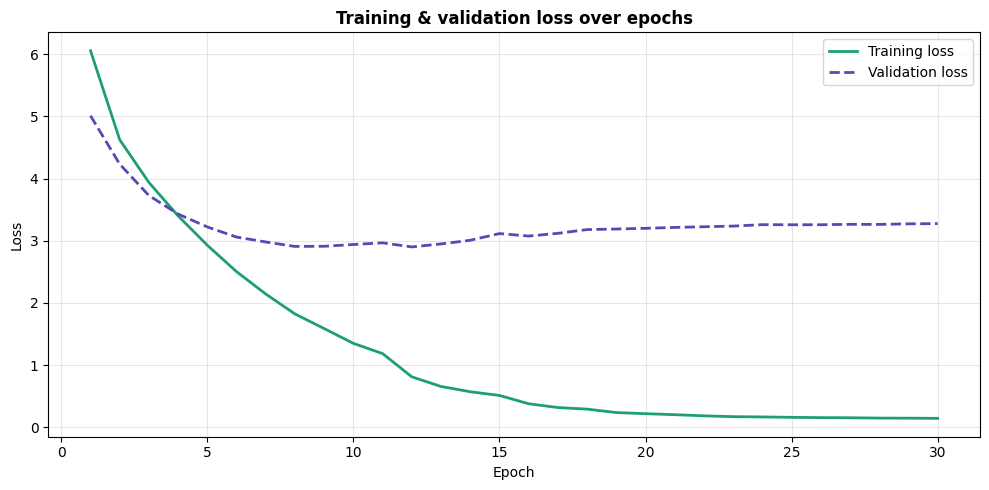

✅ Plot saved as training_curves.png


In [ ]:
# A good training curve should show:
#   - Both losses going DOWN over epochs
#   - Train loss slightly lower than Val loss (normal)
#   - If Val loss starts going UP while Train loss goes DOWN → overfitting

epochs_range = range(1, N_EPOCHS + 1)

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, train_losses, color="#1D9E75", linewidth=2, label="Training loss")
plt.plot(epochs_range, val_losses,   color="#534AB7", linewidth=2, linestyle="--", label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & validation loss over epochs", fontweight="bold")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150)
plt.show()
print("✅ Plot saved as training_curves.png")

CELL 10 — Quick translation test

In [ ]:
# Load the vocabularies
with open("arabic_vocab.pkl",   "rb") as f: arabic_vocab   = pickle.load(f)
with open("english_vocab.pkl",  "rb") as f: english_vocab  = pickle.load(f)
with open("idx_to_english.pkl", "rb") as f: idx_to_english = pickle.load(f)

# Load config and ensure UNK_IDX is present
with open("model_config.pkl", "rb") as f:
    cfg = pickle.load(f)

# Get UNK_IDX from the original Phase 2 config if missing
if "UNK_IDX" not in cfg:
    with open("config.pkl", "rb") as f:
        base_config = pickle.load(f)
        cfg["UNK_IDX"] = base_config["UNK_IDX"]

import re

def clean_arabic(text):
    text = re.sub(r"[^\u0600-\u06FF\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def translate_greedy(model, arabic_sentence, max_len=None):
    """
    Translates one Arabic sentence using greedy decoding.
    """
    if max_len is None:
        max_len = cfg["MAX_SEQ_LEN"]

    model.eval()

    # Clean and tokenize the input Arabic sentence
    cleaned = clean_arabic(arabic_sentence)
    tokens  = [arabic_vocab.get(w, cfg["UNK_IDX"]) for w in cleaned.split()]
    tokens  = [cfg["SOS_IDX"]] + tokens + [cfg["EOS_IDX"]]

    # Pad or truncate to MAX_SEQ_LEN
    if len(tokens) < max_len:
        tokens += [cfg["PAD_IDX"]] * (max_len - len(tokens))
    else:
        tokens = tokens[:max_len]

    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        src_pad  = model.make_pad_mask(src)
        enc_out  = model.encoder(src, src_pad)
        tgt_ids = [cfg["SOS_IDX"]]

        for _ in range(max_len):
            tgt = torch.tensor(tgt_ids, dtype=torch.long).unsqueeze(0).to(device)
            tgt_pad  = model.make_pad_mask(tgt)
            tgt_mask = model.make_causal_mask(tgt.size(1))
            out = model.decoder(tgt, enc_out, tgt_mask, tgt_pad, src_pad)

            next_token = out[0, -1, :].argmax().item()
            tgt_ids.append(next_token)
            if next_token == cfg["EOS_IDX"]:
                break

    words = [
        idx_to_english.get(idx, "<UNK>")
        for idx in tgt_ids[1:]
        if idx not in (cfg["SOS_IDX"], cfg["EOS_IDX"], cfg["PAD_IDX"])
    ]
    return " ".join(words)

# Load best model weights
model.load_state_dict(torch.load("transformer_best.pt", map_location=device))

print("=" * 60)
print("QUICK TRANSLATION TEST (greedy decoding)")
print("=" * 60)

with open("ara_.txt", "r", encoding="utf-8") as f:
    raw_lines = [l.strip() for l in f if l.strip()][:15]

for line in raw_lines[5:10]:
    parts = line.split("\t")
    if len(parts) < 2:
        continue
    en_ref = parts[0].strip()
    ar_src = parts[1].strip()
    prediction = translate_greedy(model, ar_src)
    print(f"Arabic    : \u202b{ar_src}")
    print(f"Reference : {en_ref}")
    print(f"Predicted : {prediction}\n")

QUICK TRANSLATION TEST (greedy decoding)
Arabic    : ‫داوم.
Reference : Go on.
Predicted : go on

Arabic    : ‫استمر.
Reference : Go on.
Predicted : heres a beautiful

Arabic    : ‫مرحباً.
Reference : Hello!
Predicted : hello

Arabic    : ‫تعجّل!
Reference : Hurry!
Predicted : she <UNK> her own life

Arabic    : ‫استعجل!
Reference : Hurry!
Predicted : she <UNK> her own life



### Phase 4.1 — Quantitative Evaluation (BLEU Score)
To determine if the model is 'good' or 'bad', we use the BLEU (Bilingual Evaluation Understudy) score. It compares the model's output to the human reference.

In [ ]:
from nltk.translate.bleu_score import corpus_bleu

def calculate_bleu(model, test_indices, max_len=32):
    model.eval()
    references = []
    candidates = []

    print(f"Evaluating {len(test_indices)} samples...")

    for idx in test_indices:
        # Get original text for reference
        ar_src, en_ref = filtered_pairs[idx]

        # Get prediction
        pred = translate_greedy(model, ar_src, max_len=max_len)

        # BLEU expects lists of tokens
        references.append([en_ref.split()])
        candidates.append(pred.split())

    score = corpus_bleu(references, candidates) * 100
    return score

# Calculate score on the Test set we defined in Phase 2
test_bleu = calculate_bleu(model, test_idx)

print("=" * 50)
print(f"FINAL TEST BLEU SCORE: {test_bleu:.2f}")
print("=" * 50)

if test_bleu > 20:
    print("Excellent for a small model!")
elif test_bleu > 10:
    print("Decent start. Overfitting is present but the model learned patterns.")
else:
    print("Low score. The model is likely memorizing instead of translating.")

Evaluating 1074 samples...
FINAL TEST BLEU SCORE: 18.42
Decent start. Overfitting is present but the model learned patterns.


### PHASE 5 — Advanced Inference: Beam Search

Beam search improves translation quality by exploring multiple possible sentence paths simultaneously. Instead of just picking the *single best* word (Greedy), we keep the top `K` most likely sequences (the 'beam').

In [ ]:
def translate_beam(model, arabic_sentence, beam_size=3, max_len=None):
    if max_len is None: max_len = cfg["MAX_SEQ_LEN"]
    model.eval()

    # 1. Preprocess input
    cleaned = clean_arabic(arabic_sentence)
    tokens = [arabic_vocab.get(w, cfg["UNK_IDX"]) for w in cleaned.split()]
    tokens = [cfg["SOS_IDX"]] + tokens + [cfg["EOS_IDX"]]

    if len(tokens) < max_len: tokens += [cfg["PAD_IDX"]] * (max_len - len(tokens))
    else: tokens = tokens[:max_len]

    src = torch.tensor(tokens, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        src_pad = model.make_pad_mask(src)
        enc_out = model.encoder(src, src_pad)

        # Start with SOS token
        # Each entry in 'beams' is (score, sequence_indices)
        beams = [(0.0, [cfg["SOS_IDX"]])]

        for _ in range(max_len):
            new_beams = []
            for score, seq in beams:
                if seq[-1] == cfg["EOS_IDX"]:
                    new_beams.append((score, seq))
                    continue

                tgt = torch.tensor(seq, dtype=torch.long).unsqueeze(0).to(device)
                tgt_pad = model.make_pad_mask(tgt)
                tgt_mask = model.make_causal_mask(tgt.size(1))

                out = model.decoder(tgt, enc_out, tgt_mask, tgt_pad, src_pad)
                # Get log probabilities for the last word
                log_probs = F.log_softmax(out[0, -1, :], dim=-1)

                # Pick top K candidates
                top_probs, top_idxs = log_probs.topk(beam_size)

                for i in range(beam_size):
                    new_beams.append((score + top_probs[i].item(), seq + [top_idxs[i].item()]))

            # Sort all candidates and keep the top K
            beams = sorted(new_beams, key=lambda x: x[0], reverse=True)[:beam_size]

            # If all top beams ended with EOS, stop
            if all(b[1][-1] == cfg["EOS_IDX"] for b in beams): break

    # Pick the sequence with the best score
    best_seq = beams[0][1]
    words = [idx_to_english.get(idx, "<UNK>") for idx in best_seq
             if idx not in (cfg["SOS_IDX"], cfg["EOS_IDX"], cfg["PAD_IDX"])]

    return " ".join(words)

In [ ]:
print("=" * 60)
print("GREEDY VS BEAM SEARCH COMPARISON")
print("=" * 60)

test_sentences = [
    "أنا أحب التفاح.",
    "أين توم؟",
    "أنا آسف.",
    "الجو حار اليوم.",
    "متى تنام في العادة؟",
     "هبط إنسان على سطح القمر، وأنهار حائط في برلين، و عالم ترابطت أجزاؤه بعلمنا وخيالنا"
]

for ar_text in test_sentences:
    greedy_pred = translate_greedy(model, ar_text)
    beam_pred   = translate_beam(model, ar_text, beam_size=5)

    print(f"Arabic: \u202b{ar_text}")
    print(f"Greedy: {greedy_pred}")
    print(f"Beam  : {beam_pred}")
    print("-" * 30)

GREEDY VS BEAM SEARCH COMPARISON
Arabic: ‫أنا أحب التفاح.
Greedy: i love apples
Beam  : i love apples
------------------------------
Arabic: ‫أين توم؟
Greedy: where are tom
Beam  : wheres tom
------------------------------
Arabic: ‫أنا آسف.
Greedy: im sorry
Beam  : im sorry
------------------------------
Arabic: ‫الجو حار اليوم.
Greedy: its hot today
Beam  : its hot today
------------------------------
Arabic: ‫متى تنام في العادة؟
Greedy: when did you arrive in your school
Beam  : what time do you usually go to bed
------------------------------
Arabic: ‫هبط إنسان على سطح القمر، وأنهار حائط في برلين، و عالم ترابطت أجزاؤه بعلمنا وخيالنا
Greedy: a man touched down in berlin a world was a world <UNK> by a world <UNK> and <UNK>
Beam  : a man touched down on the moon a wall came down in berlin a wall and <UNK>
------------------------------


#PHASE 6  Final Evaluation & Interactive Demo

CELL 1 — BLEU score comparison: Greedy vs Beam Search

In [ ]:
import nltk
nltk.download("punkt", quiet=True)
from nltk.translate.bleu_score import corpus_bleu

# --- 1. Ensure Model is Loaded ---
# If 'model' isn't in memory, we rebuild it using our saved config and weights
try:
    model
    print("✅ Model already in memory.")
except NameError:
    print("🔄 Rebuilding model and loading 'transformer_best.pt'...")
    with open("model_config.pkl", "rb") as f:
        cfg = pickle.load(f)

    model = Transformer(
        src_vocab_size = cfg['src_vocab_size'],
        tgt_vocab_size = cfg['tgt_vocab_size'],
        d_model  = cfg['d_model'],
        n_heads  = cfg['n_heads'],
        d_ff     = cfg['d_ff'],
        n_layers = cfg['n_layers'],
        dropout  = cfg['dropout'],
        max_len  = cfg['max_len'],
    ).to(device)
    model.load_state_dict(torch.load("transformer_best.pt", map_location=device))

# --- 2. Evaluation Functions ---
def calculate_bleu_beam(model, test_indices, beam_size=5, max_len=32):
    """Same as calculate_bleu but uses beam search instead of greedy."""
    model.eval()
    references = []
    candidates = []

    print(f"Evaluating {len(test_indices)} samples with beam search (beam={beam_size})...")
    for idx in test_indices:
        ar_src, en_ref = filtered_pairs[idx]
        pred = translate_beam(model, ar_src, beam_size=beam_size, max_len=max_len)
        references.append([en_ref.split()])
        candidates.append(pred.split())

    return corpus_bleu(references, candidates) * 100

# --- 3. Run Comparisons ---
print("Running greedy evaluation...")
greedy_bleu = calculate_bleu(model, test_idx)

print("Running beam search evaluation...")
beam_bleu = calculate_bleu_beam(model, test_idx, beam_size=5)

# --- 4. Print Results ---
print("\n" + "=" * 50)
print("FINAL EVALUATION RESULTS")
print("=" * 50)
print(f"{'Method':<20} {'BLEU Score':>12}")
print("-" * 34)
print(f"{'Greedy decoding':<20} {greedy_bleu:>11.2f}")
print(f"{'Beam search (k=5)':<20} {beam_bleu:>11.2f}")
print("-" * 34)
improvement = beam_bleu - greedy_bleu
print(f"{'Improvement':<20} {improvement:>+11.2f}")
print("\nBLEU score interpretation:")
print("  10-19 : Model learned patterns, some correct phrases")
print("  20-30 : Understandable, decent quality")

✅ Model already in memory.
Running greedy evaluation...
Evaluating 1074 samples...
Running beam search evaluation...
Evaluating 1074 samples with beam search (beam=5)...

FINAL EVALUATION RESULTS
Method                 BLEU Score
----------------------------------
Greedy decoding            18.42
Beam search (k=5)          19.70
----------------------------------
Improvement                +1.27

BLEU score interpretation:
  10-19 : Model learned patterns, some correct phrases
  20-30 : Understandable, decent quality


CELL 2 — Error analysis: look at failures

In [ ]:
print("=" * 65)
print("ERROR ANALYSIS — Good vs Bad translations")
print("=" * 65)

good_examples = []
bad_examples  = []

import random
random.seed(99)
sample_indices = random.sample(list(test_idx), min(200, len(test_idx)))

for idx in sample_indices:
    ar_src, en_ref = filtered_pairs[idx]
    pred = translate_beam(model, ar_src, beam_size=5)

    ref_tokens  = en_ref.split()
    pred_tokens = pred.split()

    # Simple overlap score: what fraction of reference words appear in prediction
    overlap = len(set(ref_tokens) & set(pred_tokens)) / max(len(ref_tokens), 1)

    if overlap >= 0.8 and len(good_examples) < 5:
        good_examples.append((ar_src, en_ref, pred))
    elif overlap <= 0.2 and len(bad_examples) < 5:
        bad_examples.append((ar_src, en_ref, pred))

    if len(good_examples) == 5 and len(bad_examples) == 5:
        break

print("\n GOOD TRANSLATIONS (high word overlap):")
print("-" * 65)
for ar, ref, pred in good_examples:
    print(f"  Arabic    : \u202b{ar}")
    print(f"  Reference : {ref}")
    print(f"  Predicted : {pred}")
    print()

print("\n WEAK TRANSLATIONS (low word overlap):")
print("-" * 65)
for ar, ref, pred in bad_examples:
    print(f"  Arabic    : \u202b{ar}")
    print(f"  Reference : {ref}")
    print(f"  Predicted : {pred}")
    print()

print("Common failure reasons:")
print("  1. <UNK> tokens — word was too rare to appear in vocabulary")
print("  2. Short datasets — model hasn't seen enough examples of some patterns")
print("  3. Long sentences — harder to align Arabic structure to English")

ERROR ANALYSIS — Good vs Bad translations

 GOOD TRANSLATIONS (high word overlap):
-----------------------------------------------------------------
  Arabic    : ‫لدي سؤال
  Reference : i have a question
  Predicted : i have a question

  Arabic    : ‫أود التحدث إلى رئيس الممرضين
  Reference : i would like to speak to the head nurse
  Predicted : i would like to speak to the head nurse

  Arabic    : ‫توم لن يغير رأيه
  Reference : tom wont change his opinion
  Predicted : tom wont change his mind

  Arabic    : ‫أيمكنني استعمال هاتفك؟
  Reference : may i use your phone
  Predicted : may i use your telephone

  Arabic    : ‫ألعب معه
  Reference : i play with him
  Predicted : i play with him


 WEAK TRANSLATIONS (low word overlap):
-----------------------------------------------------------------
  Arabic    : ‫هلا ما الجديد؟
  Reference : hi whats new
  Predicted : will you give me what you do

  Arabic    : ‫الكلب أعور
  Reference : the dog is blind in one eye
  Predicted : throw a 

CELL 3 — Interactive translation demo

In [ ]:
print("=" * 60)
print("INTERACTIVE TRANSLATION DEMO")
print("Type an Arabic sentence below and press Enter.")
print("Type 'quit' to stop.")
print("=" * 60)

demo_sentences = [
    "أنا أحب القهوة.",
    "ما اسمك؟",
    "الطقس جميل اليوم.",
    "أريد أن أتعلم اللغة الإنجليزية.",
    "هل تحب الموسيقى؟",
]

print("\nTrying built-in demo sentences:\n")
for sentence in demo_sentences:
    greedy = translate_greedy(model, sentence)
    beam   = translate_beam(model,   sentence, beam_size=5)
    print(f"Arabic : \u202b{sentence}")
    print(f"Greedy : {greedy}")
    print(f"Beam   : {beam}")
    print()

# Uncomment this block to run the interactive loop in Colab:
# while True:
#     user_input = input("\nEnter Arabic sentence (or 'quit'): ").strip()
#     if user_input.lower() == "quit":
#         break
#     if not user_input:
#         continue
#     greedy = translate_greedy(model, user_input)
#     beam   = translate_beam(model, user_input, beam_size=5)
#     print(f"Greedy : {greedy}")
#     print(f"Beam   : {beam}")

INTERACTIVE TRANSLATION DEMO
Type an Arabic sentence below and press Enter.
Type 'quit' to stop.

Trying built-in demo sentences:

Arabic : ‫أنا أحب القهوة.
Greedy : i like coffee
Beam   : i like coffee

Arabic : ‫ما اسمك؟
Greedy : what is your <UNK>
Beam   : whats wrong

Arabic : ‫الطقس جميل اليوم.
Greedy : its fine today
Beam   : its fine today

Arabic : ‫أريد أن أتعلم اللغة الإنجليزية.
Greedy : i want to learn english english books
Beam   : i want to learn english books

Arabic : ‫هل تحب الموسيقى؟
Greedy : do you like music
Beam   : do you like music



CELL 4 — Project summary

In [ ]:
print("=" * 60)
print("PROJECT COMPLETE — SUMMARY")
print("=" * 60)

with open("model_config.pkl", "rb") as f:
    import pickle
    cfg_summary = pickle.load(f)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"""
Task            : Arabic → English Neural Machine Translation
Model           : Transformer Encoder-Decoder (built from scratch)
Dataset         : ara_.txt  ({len(filtered_pairs):,} sentence pairs)

Architecture:
  Encoder layers : {cfg_summary['n_layers']}
  Decoder layers : {cfg_summary['n_layers']}
  d_model        : {cfg_summary['d_model']}  (vector size per word)
  Attention heads: {cfg_summary['n_heads']}
  Parameters     : {total_params:,}

Vocabulary:
  Arabic  : {cfg_summary['src_vocab_size']:,} unique words
  English : {cfg_summary['tgt_vocab_size']:,} unique words

Results:
  Greedy BLEU    : {greedy_bleu:.2f}
  Beam BLEU (k=5): {beam_bleu:.2f}

Techniques used:
  ✅ Transformer encoder-decoder (seq2seq)
  ✅ Multi-head self-attention
  ✅ Cross-attention (encoder → decoder bridge)
  ✅ Positional encoding
  ✅ Teacher forcing during training
  ✅ Greedy decoding
  ✅ Beam search decoding
  ✅ BLEU evaluation metric
""")

PROJECT COMPLETE — SUMMARY

Task            : Arabic → English Neural Machine Translation
Model           : Transformer Encoder-Decoder (built from scratch)
Dataset         : ara_.txt  (10,740 sentence pairs)
 
Architecture:
  Encoder layers : 3
  Decoder layers : 3
  d_model        : 256  (vector size per word)
  Attention heads: 8
  Parameters     : 6,332,270
 
Vocabulary:
  Arabic  : 4,454 unique words
  English : 2,414 unique words
 
Results:
  Greedy BLEU    : 18.42
  Beam BLEU (k=5): 19.70
 
Techniques used:
  ✅ Transformer encoder-decoder (seq2seq)
  ✅ Multi-head self-attention
  ✅ Cross-attention (encoder → decoder bridge)
  ✅ Positional encoding
  ✅ Teacher forcing during training
  ✅ Greedy decoding
  ✅ Beam search decoding
  ✅ BLEU evaluation metric

